In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm

In [5]:
orig_phot = pd.read_csv('/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat')

In [6]:
orig_phot

,MJD,Mag,Mag_err,Flux,Flux_err,band,Instr,FilterSet
0,57982.981,17.48,0.02,2.230707e-16,4.109113e-18,Swope_i,E2V4kx4kccd,GeneralFilters
1,57982.990,18.26,0.15,2.431450e-17,3.359173e-18,FourStar_H,FourStar,GeneralFilters
2,57982.999,18.62,0.05,9.719182e-18,4.475849e-19,VISTA_Ks,VIRCAM,GeneralFilters
3,57983.000,17.83,0.15,6.180321e-17,8.538428e-18,FourStar_J,FourStar,GeneralFilters
4,57983.003,17.48,0.03,2.171782e-16,6.000855e-18,DECam_i,DECam,GeneralFilters
...,...,...,...,...,...,...,...,...
350,58000.960,20.81,0.13,1.291800e-18,1.546729e-19,FourStar_Ks,FourStar,GeneralFilters
351,58000.990,20.93,0.17,1.156632e-18,1.811005e-19,FourStar_Ks,FourStar,GeneralFilters
352,58001.992,23.37,0.48,6.900240e-19,3.050571e-19,VIMOS_z,VIMOS,GeneralFilters
353,58003.969,21.46,0.08,7.078414e-19,5.215568e-20,HAWKI_Ks,HAWKI,GeneralFilters


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_magnitude_by_band(df, time_col='MJD', mag_col='Mag', band_col='band', err_col='Mag_err',
                           color_dict=None, bands_to_plot=None):
    """
    Plots magnitude vs. time, color-coded by filter (band).

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        time_col (str): Name of time column.
        mag_col (str): Name of magnitude column.
        band_col (str): Name of band/filter column.
        color_dict (dict): Optional dict of band:color.
        bands_to_plot (list): Optional list of bands to include.
    """
    plt.figure(figsize=(14, 6))

    # Ensure proper types
    df_sorted = df.sort_values(by=time_col).copy()
    df_sorted[time_col] = pd.to_numeric(df_sorted[time_col], errors='coerce')
    df_sorted = df_sorted.dropna(subset=[time_col, mag_col])

    # Filter by selected bands, if provided
    if bands_to_plot:
        df_sorted = df_sorted[df_sorted[band_col].isin(bands_to_plot)]

    # Get unique bands
    unique_bands = df_sorted[band_col].unique()
    num_bands = len(unique_bands)
    
    # Generate colors from a wide-spectrum colormap and shuffle them
    # nipy_spectral provides excellent categorical contrast
    auto_colors = cm.nipy_spectral(np.linspace(0, 1, num_bands))
    
    # Use a fixed random seed so the shuffle is identical every time you run the code
    np.random.seed(42)
    np.random.shuffle(auto_colors)

    # Plot each band
    for i, band in enumerate(unique_bands):
        band_df = df_sorted[df_sorted[band_col] == band]
        
        color = color_dict.get(band, auto_colors[i]) if color_dict else auto_colors[i]
        
        phase = band_df[time_col] - 57982.52851852
        
        plt.errorbar(phase, band_df[mag_col], yerr=band_df[err_col],
                    label=band, color=color, alpha=0.8, fmt='o',
                    capsize=3,               
                    markeredgecolor='black', 
                    markerfacecolor=color)   

    plt.gca().invert_yaxis()
    plt.xscale('log')
    plt.xlabel('Phase from explosion (days)')
    plt.ylabel('Magnitude')
    plt.title('Magnitude vs. Time by Filter')
    
    # Move legend outside the plot so it doesn't cover your data
    plt.legend(title='Filter', fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_88116/2943589578.py:65: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


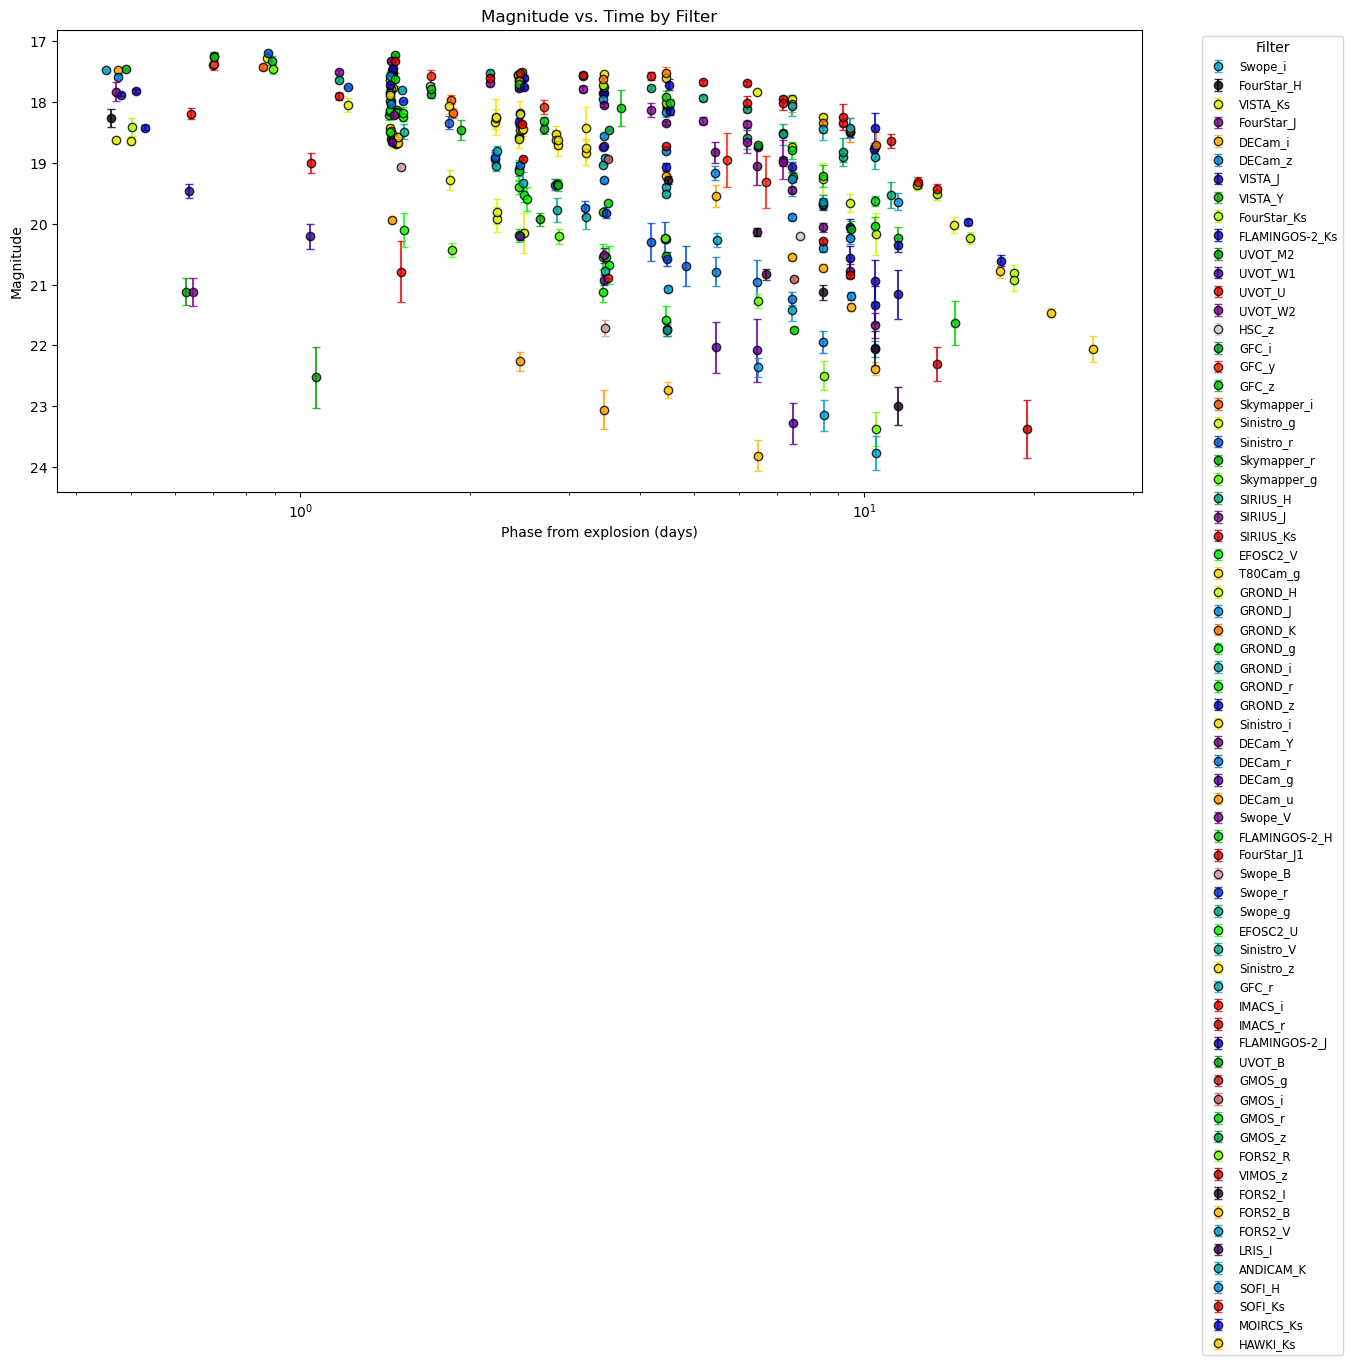

In [19]:
plot_magnitude_by_band(orig_phot)

In [ ]:
def plot_magnitude_by_suffix_groups(df, time_col='MJD', mag_col='Mag', band_col='band', err_col='Mag_err',
                                    color_dict=None):
    """
    Plots magnitude vs. time, creating a separate plot for each band suffix group,
    with a fixed x-axis across all plots for easy comparison.
    """
    # Ensure proper types and clean data
    df_sorted = df.sort_values(by=time_col).copy()
    df_sorted[time_col] = pd.to_numeric(df_sorted[time_col], errors='coerce')
    df_sorted = df_sorted.dropna(subset=[time_col, mag_col])

    # Calculate Phase for the entire DataFrame upfront
    df_sorted['Phase'] = df_sorted[time_col] - 57982.52851852

    # Extract the suffix to group by
    df_sorted['suffix'] = df_sorted[band_col].astype(str).str.split('_').str[-1].str.lower()

    # Determine global x-axis limits (filtering for Phase > 0 for the log scale)
    positive_phases = df_sorted[df_sorted['Phase'] > 0]['Phase']
    
    # We multiply by 0.9 and 1.1 to add a 10% visual padding so points 
    # on the very edges don't get cut off by the plot borders.
    global_xmin = positive_phases.min() * 0.9
    global_xmax = positive_phases.max() * 1.1

    # Get the unique suffixes to loop through
    unique_suffixes = df_sorted['suffix'].unique()

    # Loop through each suffix group and create a separate plot
    for suffix in unique_suffixes:
        
        suffix_df = df_sorted[df_sorted['suffix'] == suffix]
        unique_bands_in_plot = suffix_df[band_col].unique()
        
        plt.figure(figsize=(14, 6))

        num_bands = len(unique_bands_in_plot)
        auto_colors = cm.nipy_spectral(np.linspace(0, 1, num_bands))
        np.random.seed(42)
        np.random.shuffle(auto_colors)

        for i, band in enumerate(unique_bands_in_plot):
            band_df = suffix_df[suffix_df[band_col] == band]
            
            color = color_dict.get(band, auto_colors[i]) if color_dict else auto_colors[i]
            
            # Phase is already calculated in the DataFrame, so we just grab the column
            plt.errorbar(band_df['Phase'], band_df[mag_col], yerr=band_df[err_col],
                        label=band, color=color, alpha=0.8, fmt='o',
                        capsize=3,               
                        markeredgecolor='black', 
                        markerfacecolor=color)   

        plt.gca().invert_yaxis()
        plt.xscale('log')
        
        # Apply the fixed global x-axis limits to this plot
        plt.xlim(global_xmin, global_xmax)
        
        plt.xlabel('Phase from explosion (days)')
        plt.ylabel('Magnitude')
        plt.title(f'Magnitude vs. Time - Band Suffix: {suffix.upper()}')
        
        plt.legend(title='Filter', fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

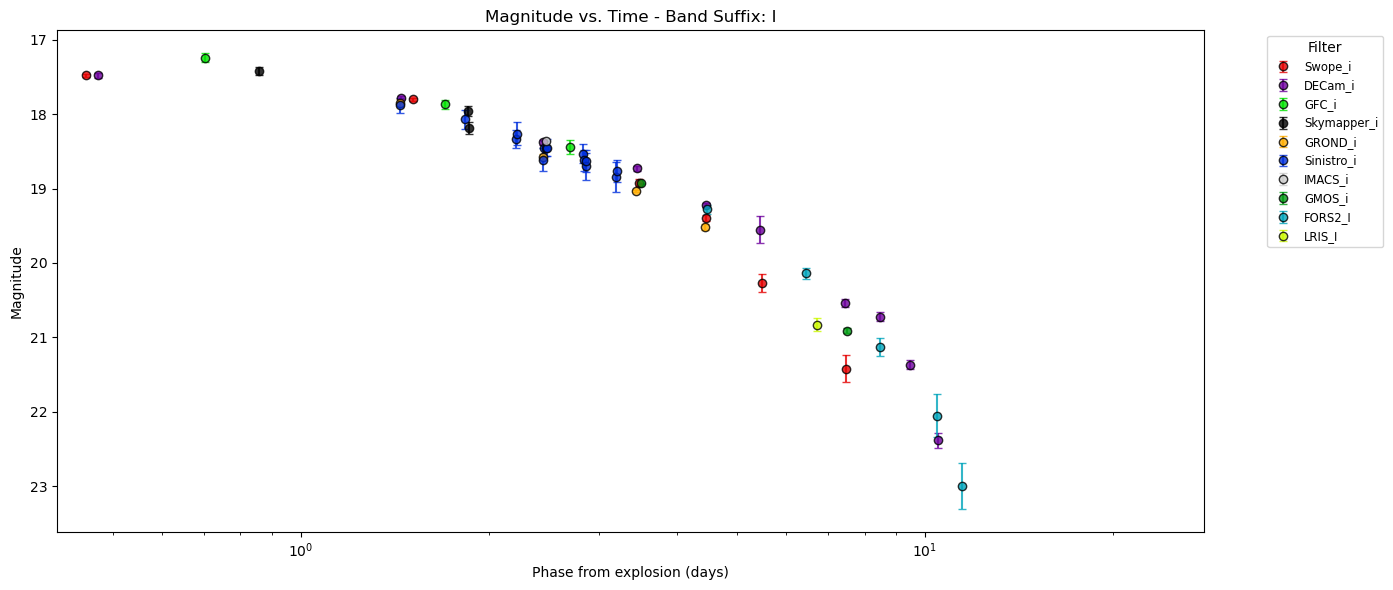

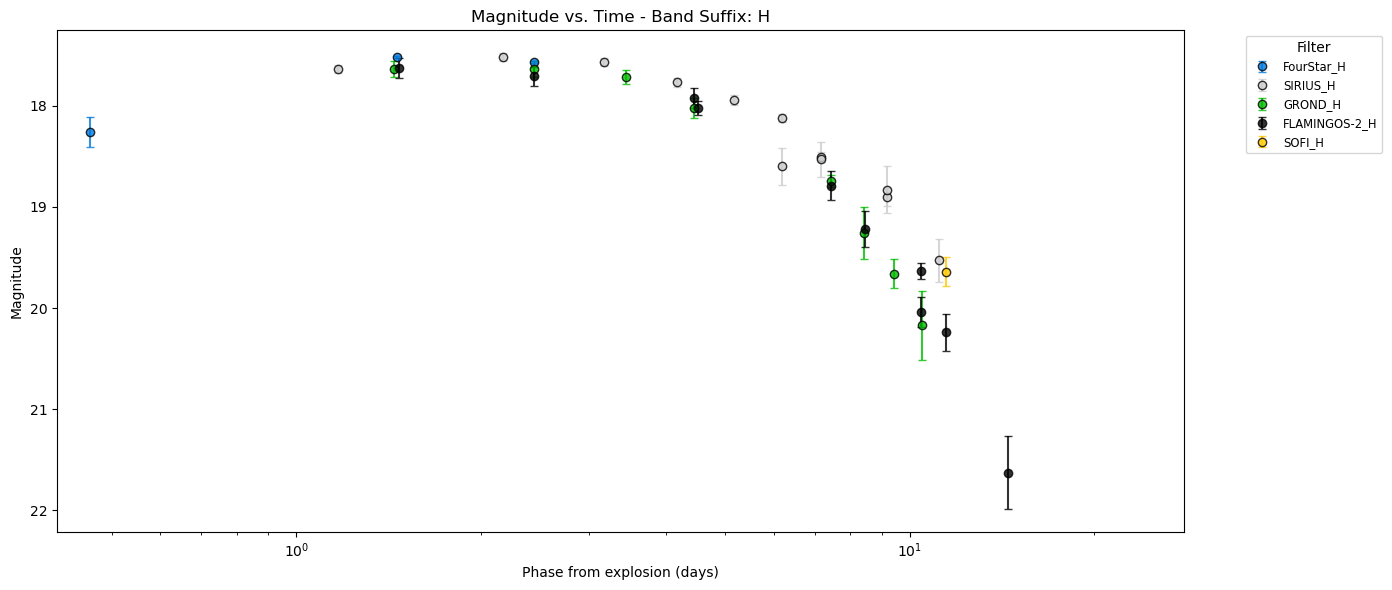

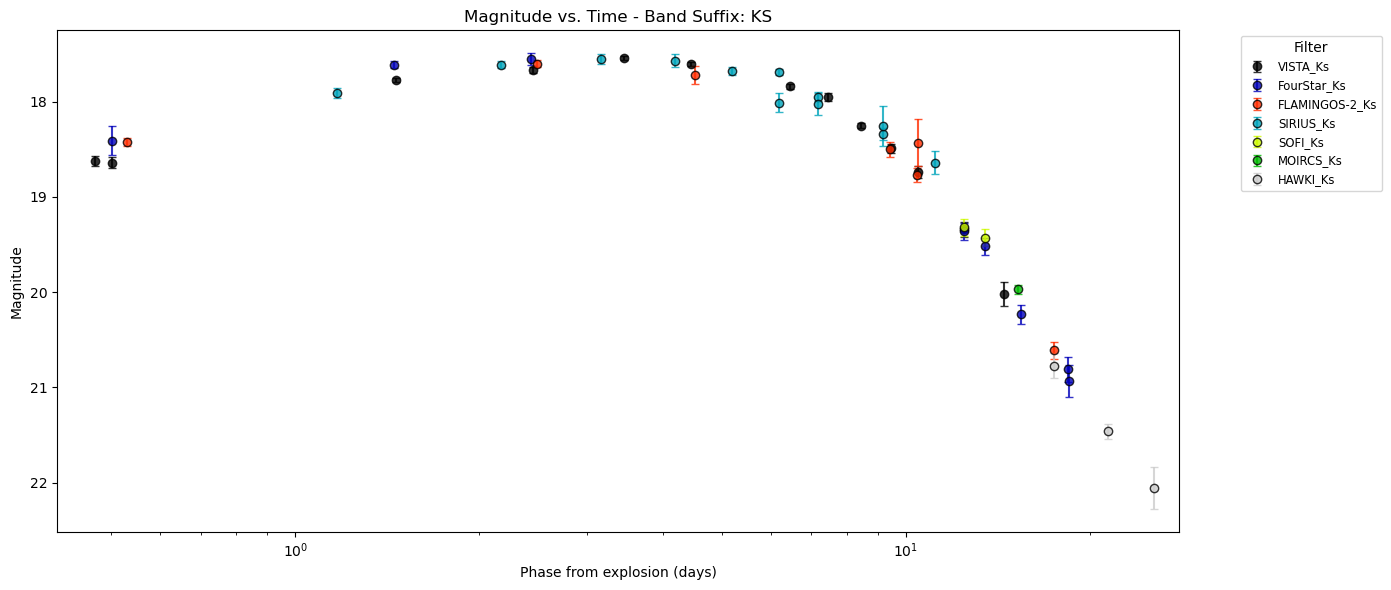

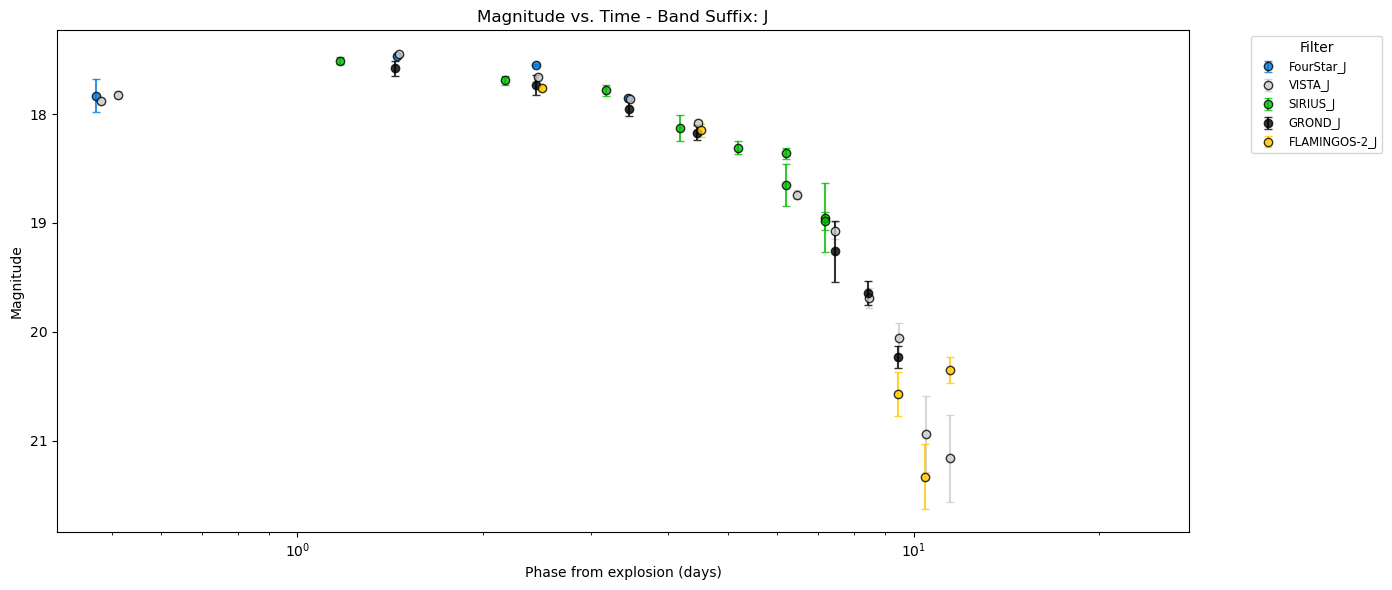

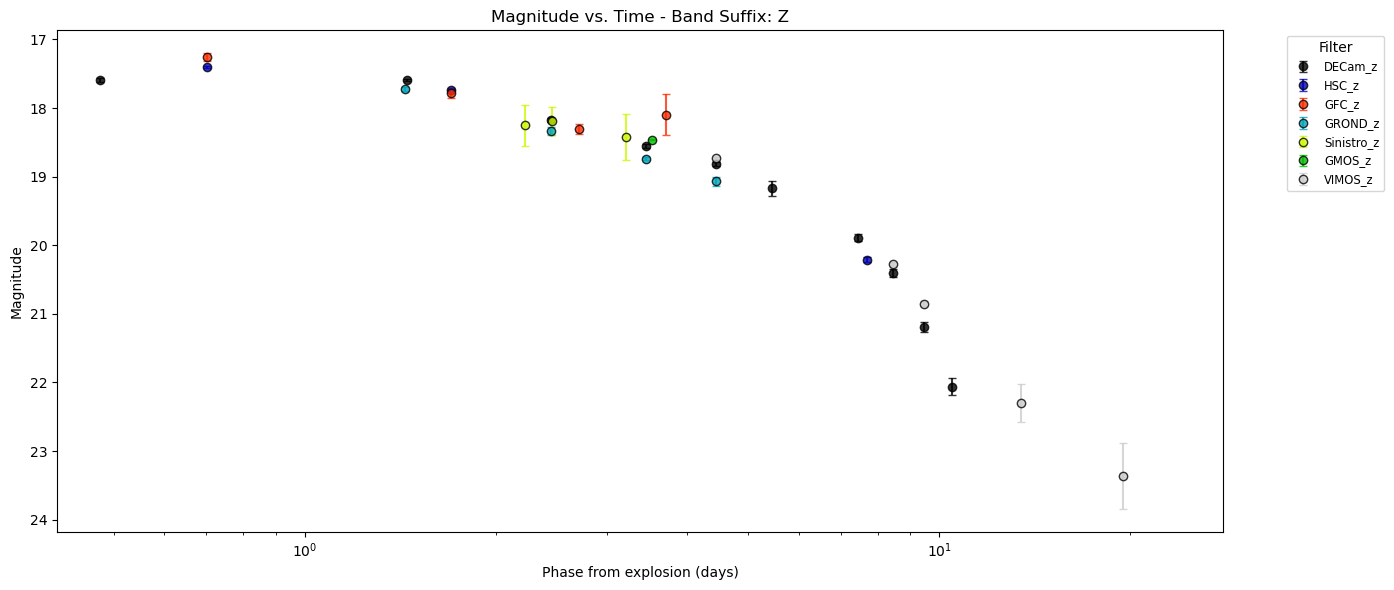

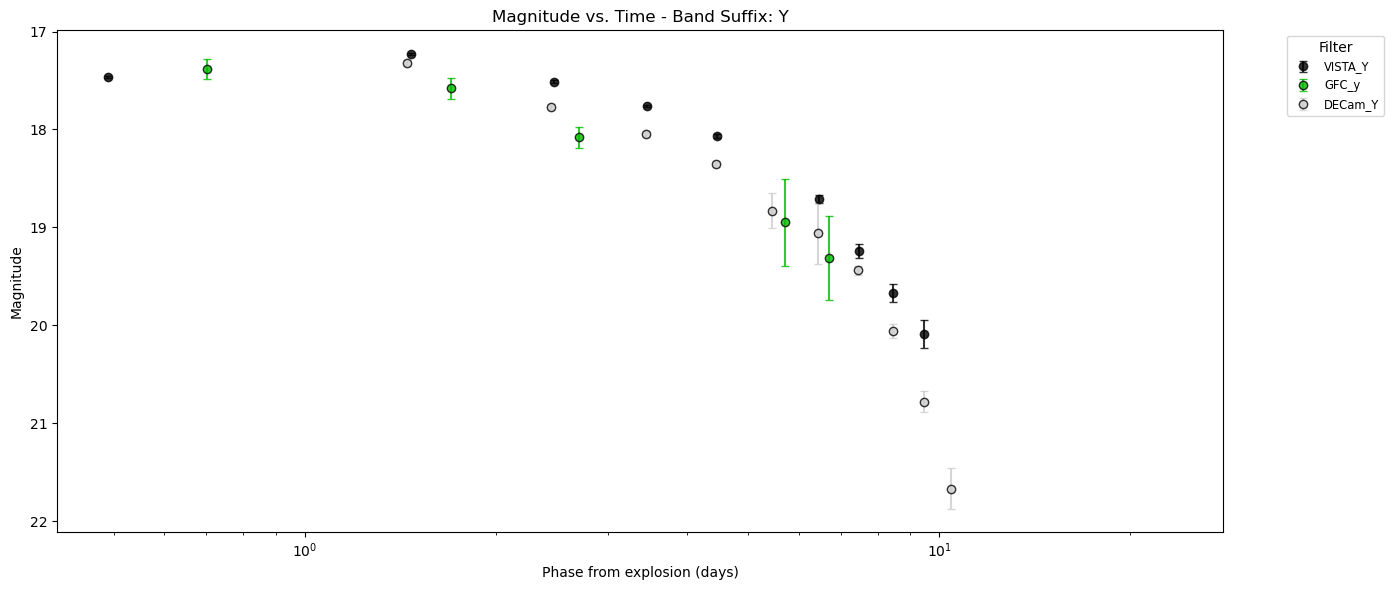

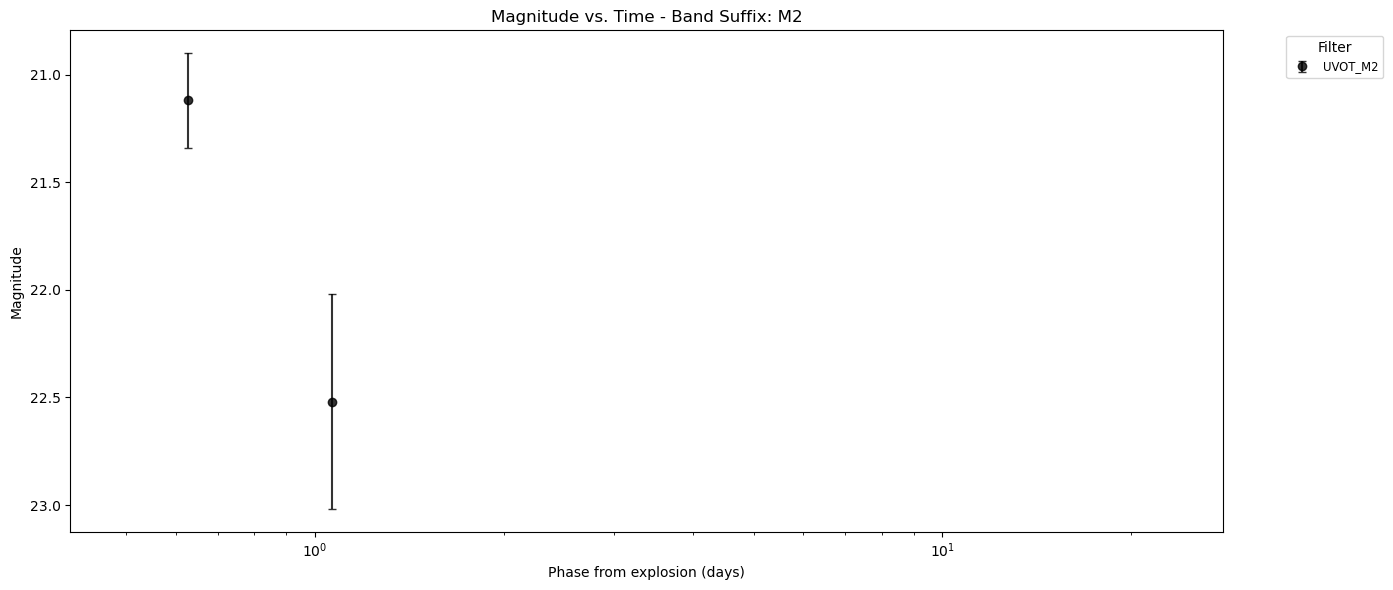

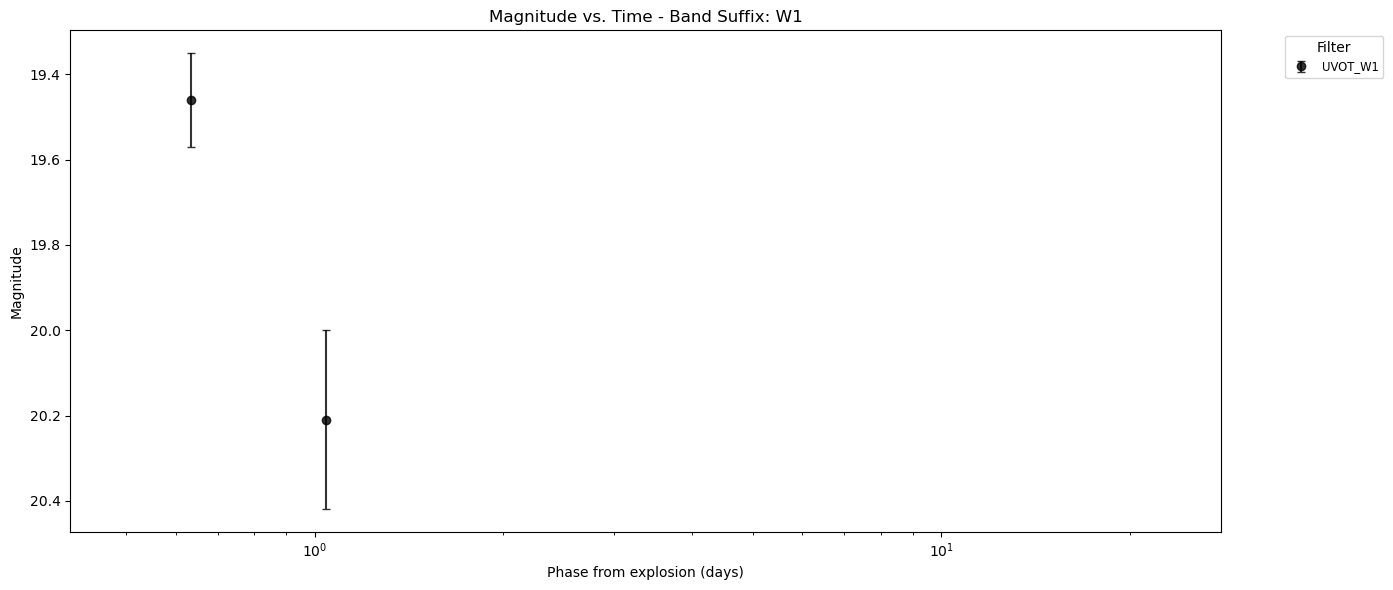

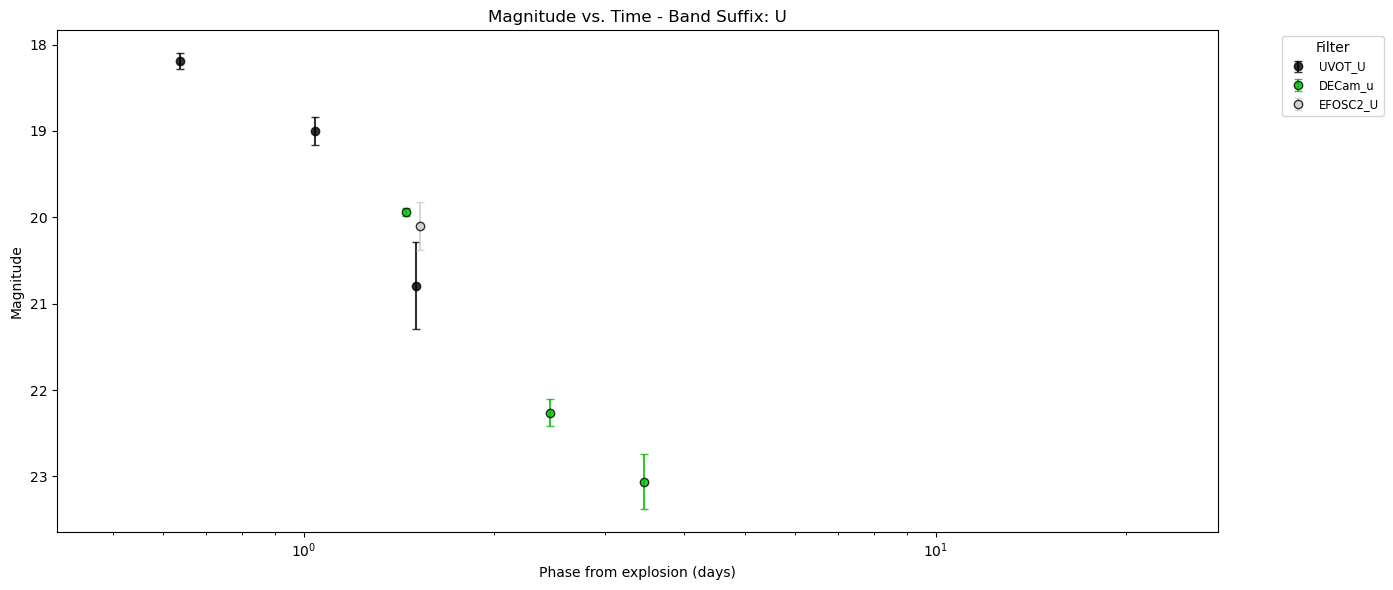

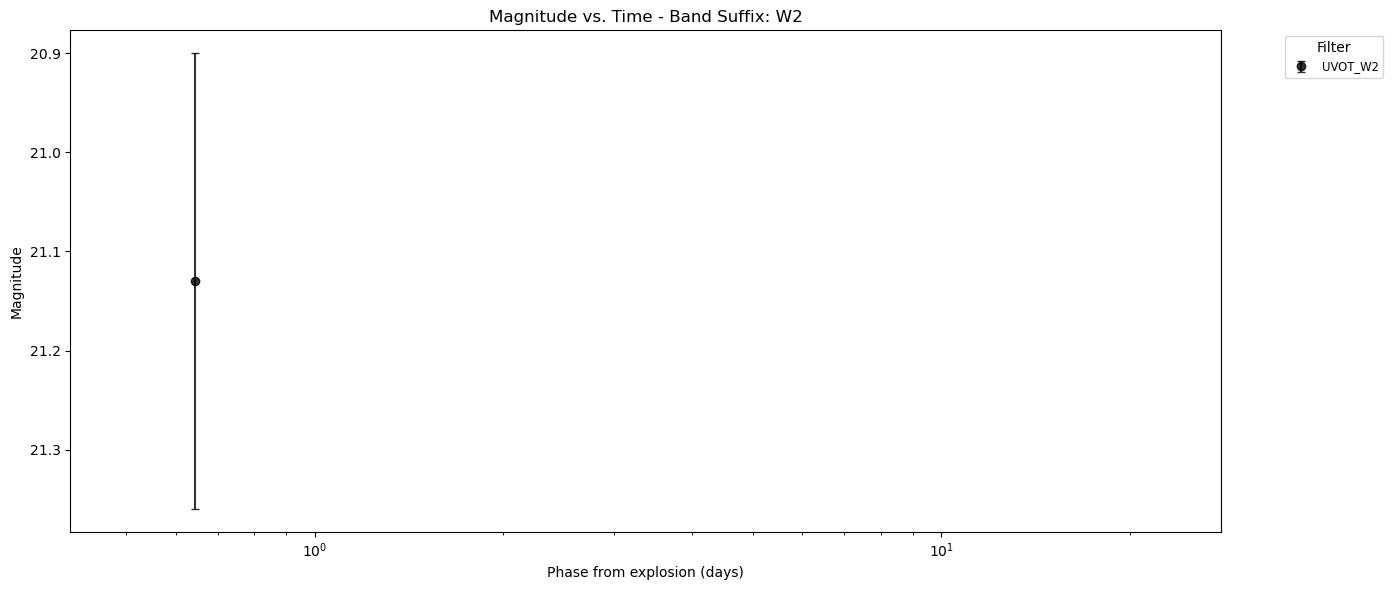

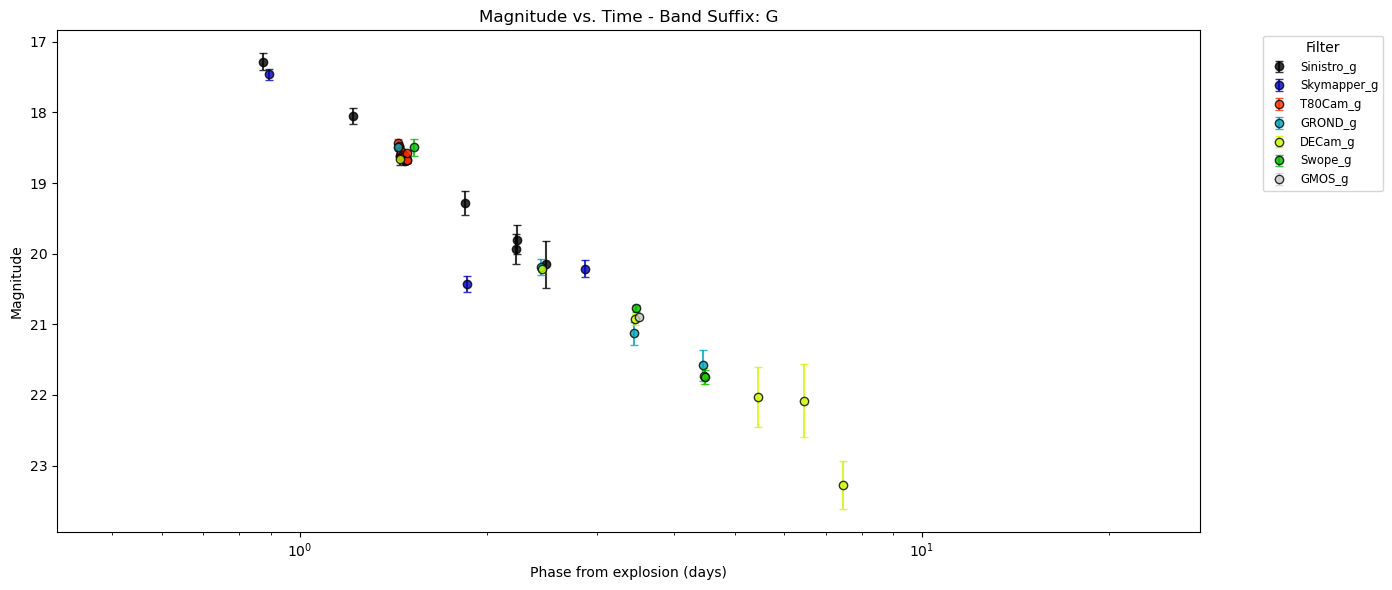

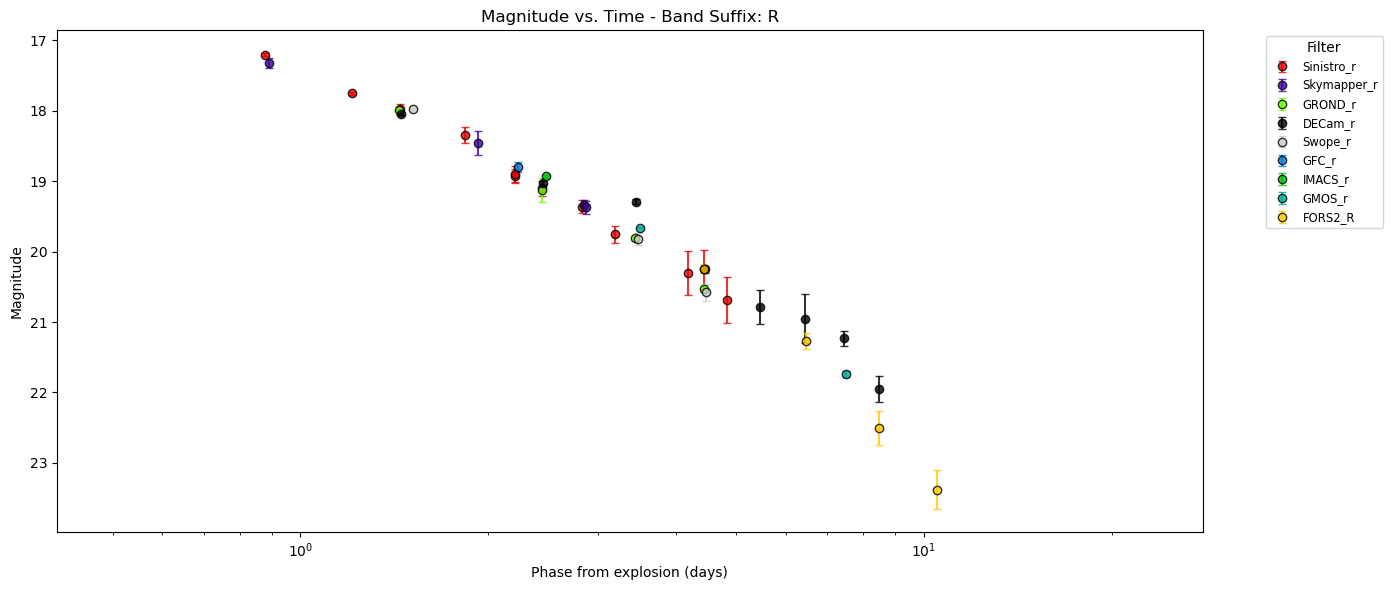

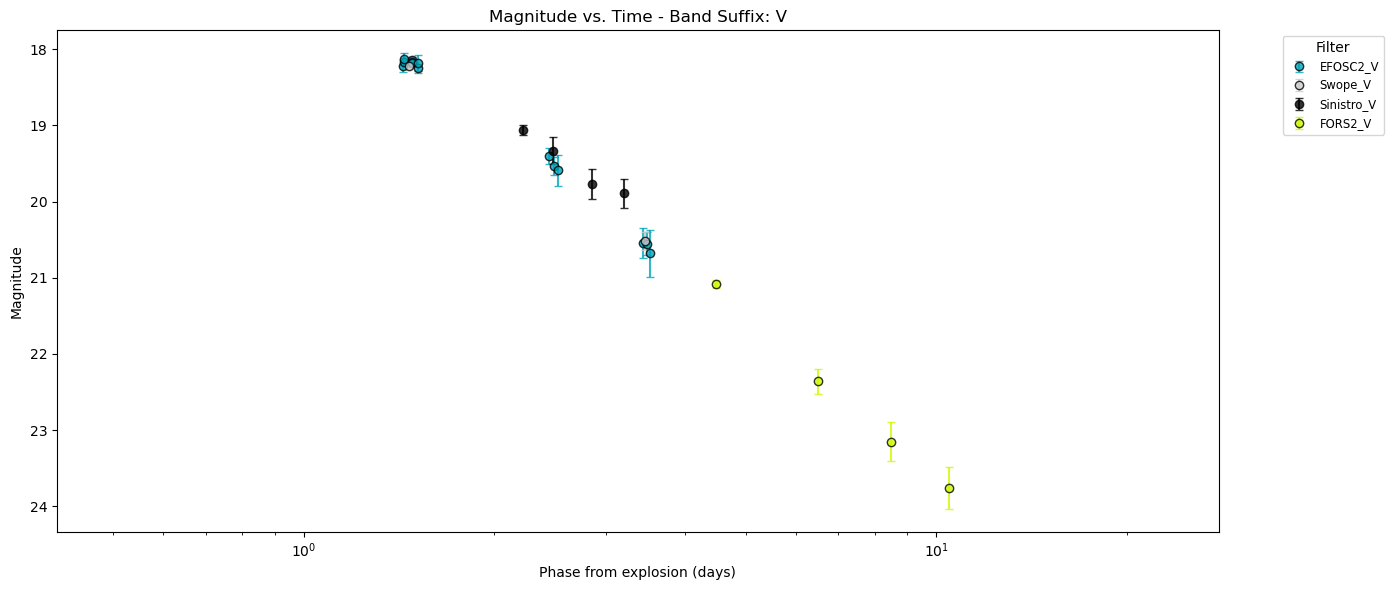

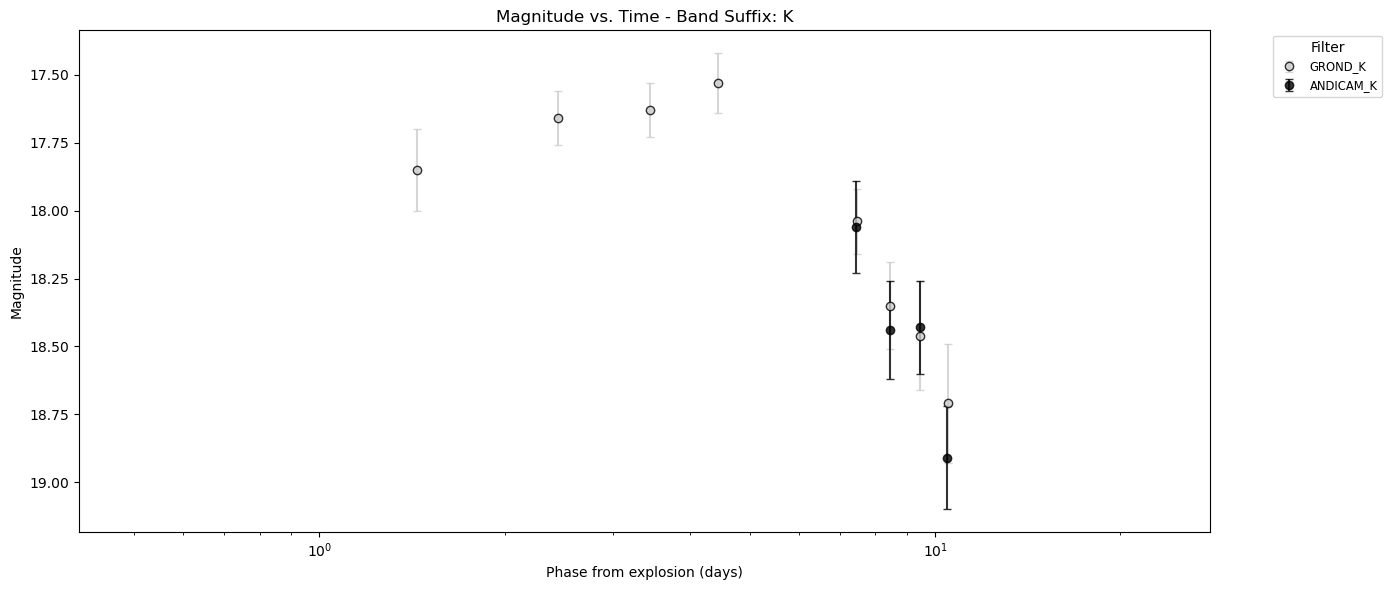

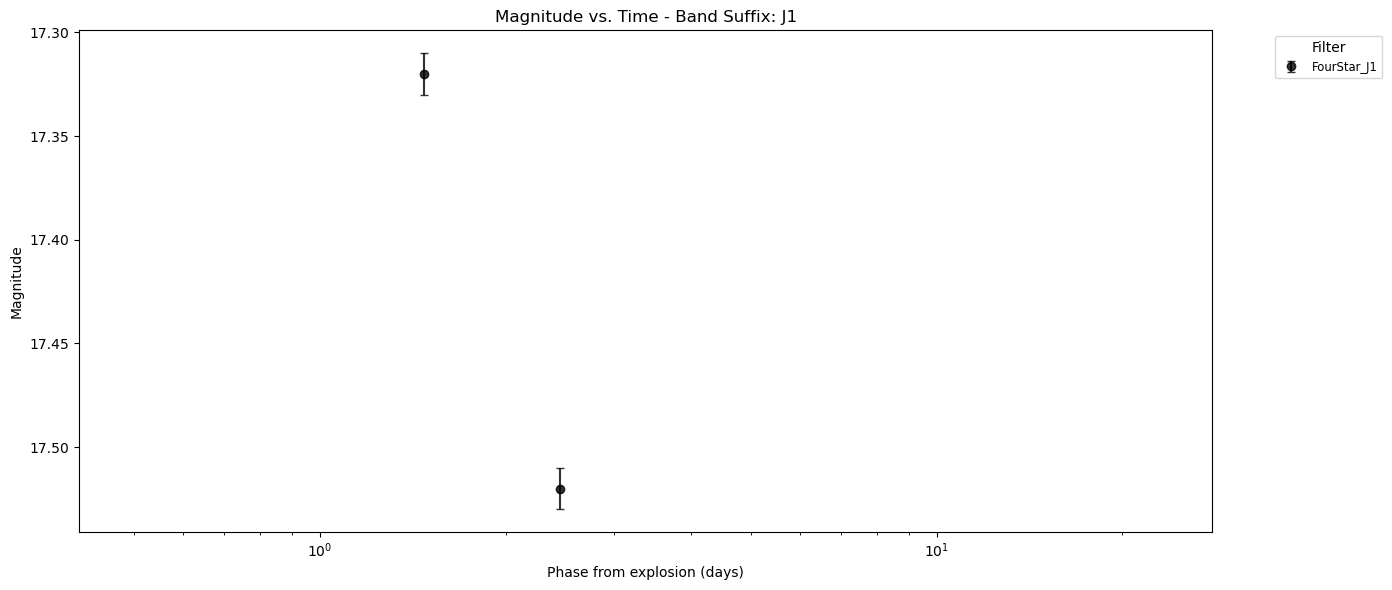

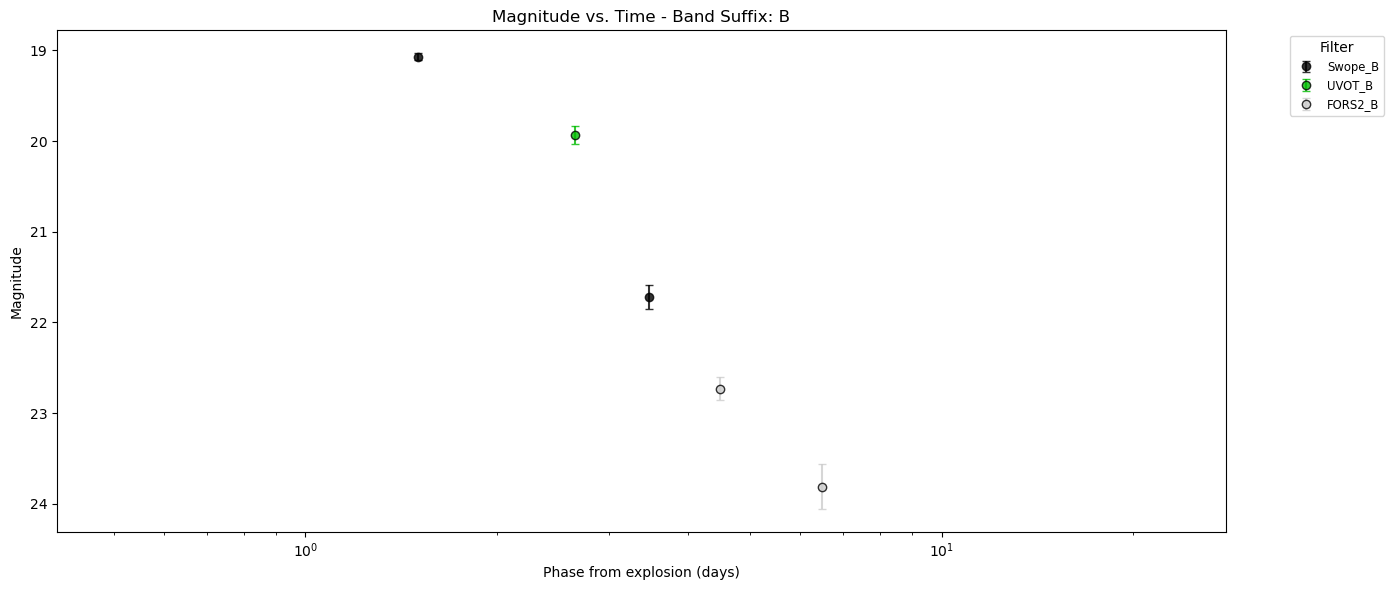

In [23]:
plot_magnitude_by_suffix_groups(orig_phot)